In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [9]:
df=pd.read_csv("D:\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jagdi\AppData\Local\Temp\ipykernel_928\4249412554.py:1: SyntaxWarning: invalid escape sequence '\d'
  df=pd.read_csv("D:\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [11]:
df.shape

(101766, 50)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [15]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [17]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [19]:
df.drop_duplicates(subset='patient_nbr',inplace=True)

In [21]:
df.replace('?',np.nan,inplace=True)

In [23]:
df.dropna(subset=['readmitted'],inplace=True)

In [25]:
df.shape

(71518, 50)

In [27]:
df['readmitted']=df['readmitted'].apply(
    lambda x:1 if x == '<30' else 0
)

In [29]:
df['readmitted'].unique()

array([0, 1], dtype=int64)

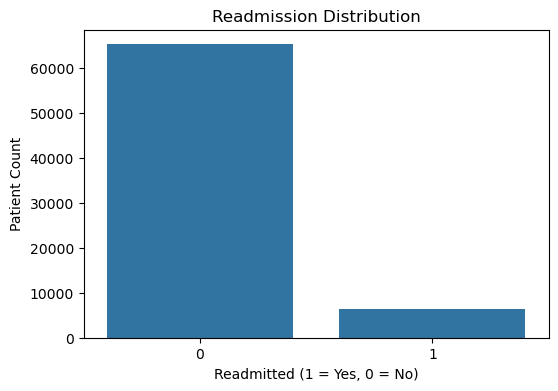

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Readmission Distribution")
plt.xlabel("Readmitted (1 = Yes, 0 = No)")
plt.ylabel("Patient Count")
plt.show()


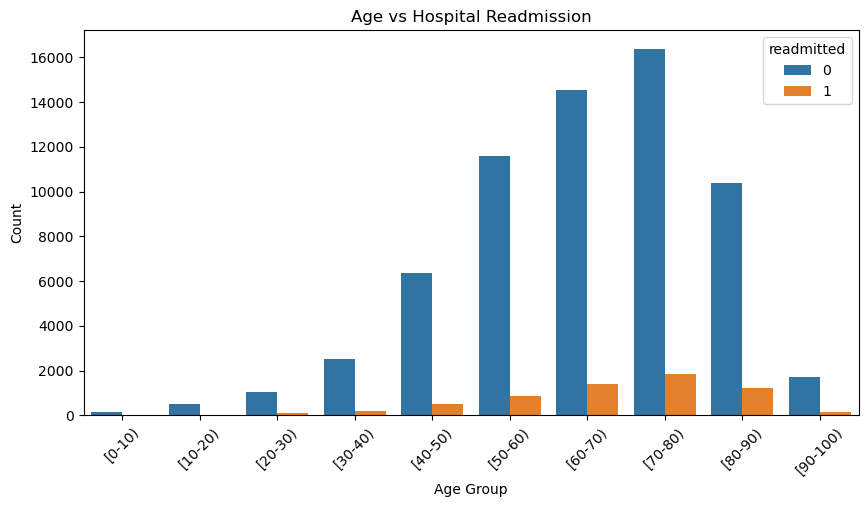

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(x='age', hue='readmitted', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Hospital Readmission")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


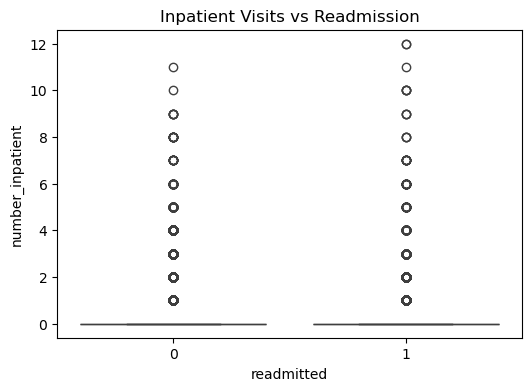

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='number_inpatient', data=df)
plt.title("Inpatient Visits vs Readmission")
plt.show()


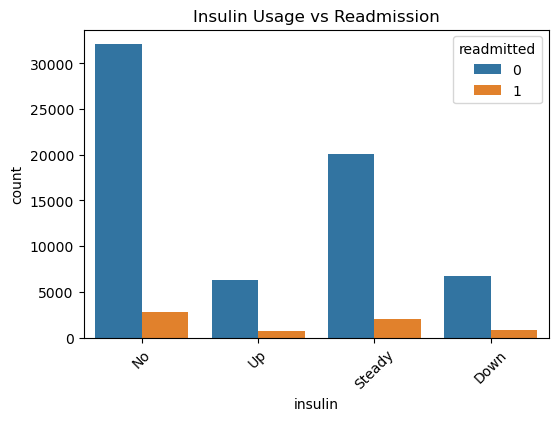

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='insulin', hue='readmitted', data=df)
plt.title("Insulin Usage vs Readmission")
plt.xticks(rotation=45)
plt.show()


In [39]:
features = [
    'age','time_in_hospital','num_lab_procedures',
    'num_procedures','num_medications',
    'number_inpatient','number_emergency',
    'number_outpatient','insulin','change'
]

df = df[features + ['readmitted']]


In [41]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])


In [43]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [45]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [46]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9135206935123042
[[13057    83]
 [ 1154    10]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     13140
           1       0.11      0.01      0.02      1164

    accuracy                           0.91     14304
   macro avg       0.51      0.50      0.49     14304
weighted avg       0.85      0.91      0.88     14304



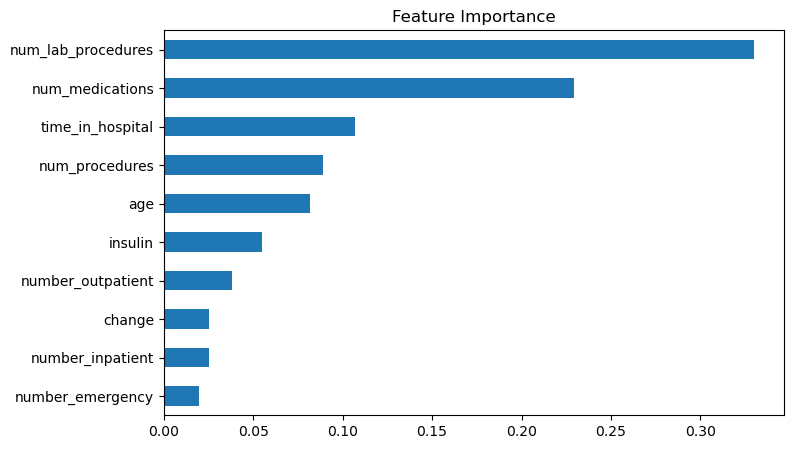

In [49]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()


In [51]:
df.to_csv("diabetes_cleaned.csv", index=False)
